#Diabet kasalligiga tashxis qoʻyish



In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
url = "https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv"

df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [25]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [26]:
df.corrwith(df['Outcome']).sort_values(ascending=False)

,0
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


### ML ga tayyorlaymiz

In [27]:
x = df.drop('Outcome',axis=1).values
y = df['Outcome']

In [28]:
from sklearn.model_selection import train_test_split
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)


StandardScaler()

In [30]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

## ML

In [31]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=14) # k-ni qiymati

knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=14)

In [32]:
y_predict = knn.predict(x_test_scaled)

## Baholash

In [33]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test,y_predict)

np.float64(0.4)

### Confusion matrix

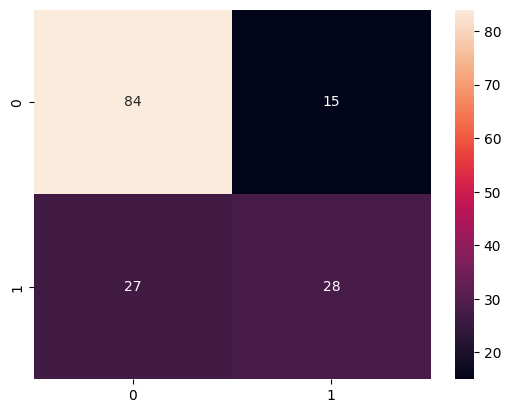

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

### Precision, recall, F1

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)
accuracy = accuracy_score(y_test, y_predict)
print(f"{precision=}\n{recall=}\n{f1=}\n{accuracy=}")

precision=0.6511627906976745
recall=0.509090909090909
f1=0.5714285714285714
accuracy=0.7272727272727273


### Cross-validation yordamida tekshiramiz

In [36]:
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn, X = x, y = y, cv = 5)

# Modelni baholash
from sklearn.metrics import classification_report
print("Classification Report: \n",classification_report(y, predict))

Classification Report: 
               precision    recall  f1-score   support

           0       0.77      0.90      0.83       500
           1       0.73      0.49      0.59       268

    accuracy                           0.76       768
   macro avg       0.75      0.70      0.71       768
weighted avg       0.75      0.76      0.74       768



## Eng yaxshi k ni topish

### `for` yordamida

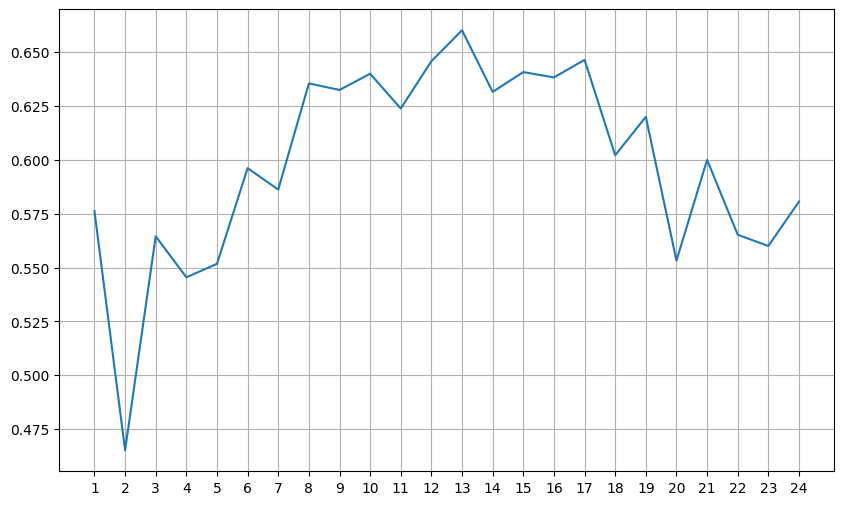

In [37]:
f1 = []
for k in range(1,25):
    knn = KNeighborsClassifier(n_neighbors=k) # k-ni qiymati
    knn.fit(x_train, y_train)
    y_predict = knn.predict(x_test)
    f1.append(f1_score(y_test, y_predict))

plt.figure(figsize=(10,6))
plt.plot(range(1,25),f1)
plt.xticks(range(1,25))
plt.grid()
plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_gscv = GridSearchCV(knn, param_grid, cv=5)

knn_gscv.fit(x, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=24),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [39]:
knn_gscv.best_params_

{'n_neighbors': np.int64(14)}

In [40]:
knn_gscv.best_score_

np.float64(0.7578558696205755)

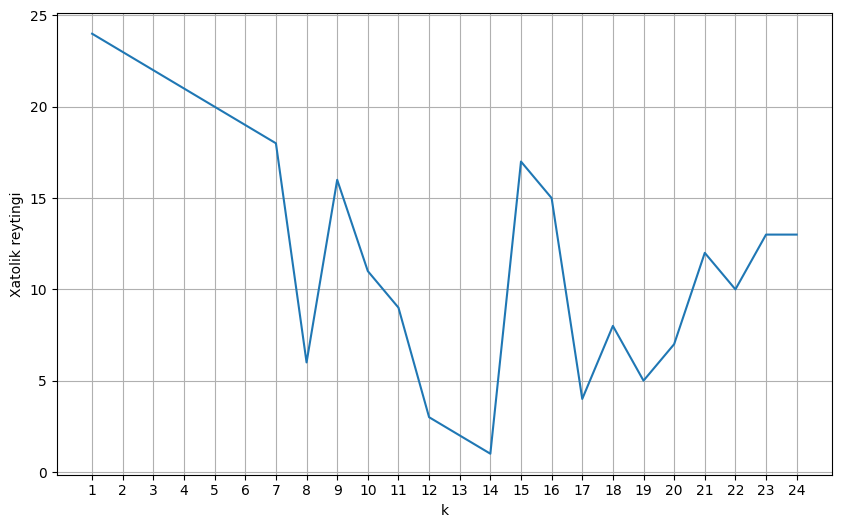

In [41]:
plt.figure(figsize=(10,6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.grid()
plt.show()

ko'rinib turibdiki eng yaxshi k 14

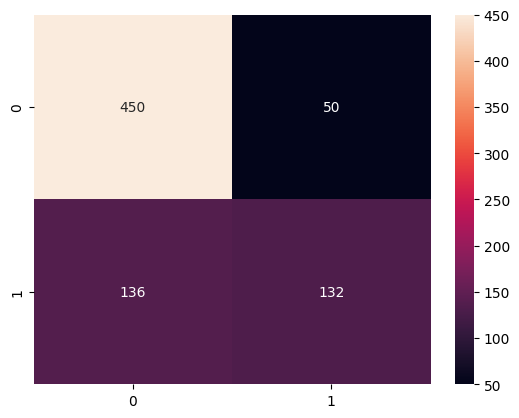

In [42]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y, predict), annot=True, fmt='d', cmap='rocket')
plt.show()